---
#  Clase 07b: Clasificación Supervisada aplicada a imágenes satelitales
---

En esta Notebook aplicaremos los clasificadores vistos en la teoría, y utilizaremos las muestras generadas en la Clase 07a para entrenar modelos. Luego, los aplicaremos para predecir las clases en toda la imagen.

### Objetivos de la notebook:

- [x] Entrenar clasificadores con nuestras muestras.
- [x] Computar las métricas de error.
- [X] Analizar cómo varía el error en función de los hiperparámetros utilizados
- [X] Generar y guardar mapas clasificados. 

### Datos con los que trabajaremos en esta Notebook:

- Recorte de la escena Sentinel-2 del dique Roggero generada en la Clase 05: **output/S2_20181006.tif**
- El archivo CSV de muestras generado en la Clase 07a: **output/Muestras_Clase07.csv**

Estas son algunas librerías que vamos a utilizar:

```python
# Bibliotecas de Python
import geopandas as gpd
import numpy as np
import pandas as pd
import rasterio
from rasterio.mask import mask
import matplotlib.pyplot as plt
import seaborn as sns

# Importación de funciones propias
import funciones as fn
```

In [3]:
# Bibliotecas de Python
import geopandas as gpd
import numpy as np
import pandas as pd
import rasterio
from rasterio.mask import mask
import matplotlib.pyplot as plt
import seaborn as sns

# Importación de funciones propias
import funciones as fn

## 1. Generación de los conjuntos X e Y

Vamos a empezar por leer nuestro conjunto de datos etiquetados en el CSV para separar en _X_ e _Y_:

```python
muestras = pd.read_csv('output/Muestras_Clase07.csv')
muestras.sample(10)
```

In [57]:
muestras = pd.read_csv('output/Clase07a_muestras_ejemplo.csv')
muestras.sample(10)

,Unnamed: 0,B02,B03,B04,B08,B11,B12,Clase
644,644,1288.0,1380.0,1443.0,1328.0,1073.0,1069.0,agua
766,766,1840.0,2172.0,2562.0,3614.0,4855.0,3915.0,suel_desn
1533,1533,1676.0,2072.0,2296.0,3724.0,3529.0,3164.0,urbano
2718,2718,1174.0,1456.0,1202.0,3952.0,2132.0,1533.0,vegetacion
404,404,1345.0,1457.0,1568.0,1400.0,1141.0,1136.0,agua
2760,2760,1297.0,1579.0,1332.0,4096.0,2310.0,1660.0,vegetacion
3337,3337,1360.0,1804.0,1444.0,5100.0,3185.0,2102.0,vegetacion
216,216,1228.0,1288.0,1367.0,1252.0,1086.0,1082.0,agua
1604,1604,1844.0,2316.0,2356.0,3450.0,4027.0,3731.0,urbano
1202,1202,1712.0,1883.0,2134.0,3078.0,4348.0,3715.0,suel_desn


Como vamos a terminar guardando un archivo GeoTiff clasificado, nos conviene trabajar con valores numéricos en lugar de cadenas de texto descriptivas. Para ello, armamos un dicccionario donde la clave sea el valor de la clase, y el valor sea el código numérico que le asignamos:

```python
clases=list(set(muestras['Clase']))
clases.sort() #ordeno las clases de mi CSV alfabéticamente
clase_dict = {clase:i for i, clase in enumerate(clases)}

print(clase_dict)
```

In [58]:
clases=list(set(muestras['Clase']))
clases.sort() #ordeno las clases de mi CSV alfabéticamente
clase_dict = {clase:i for i, clase in enumerate(clases)}

print(clase_dict)

{'agua': 0, 'suel_desn': 1, 'urbano': 2, 'vegetacion': 3}


Teniendo ese diccionario, podemos usar la función `map` de Pandas para cargar una nueva columna con el identificador numérico de Clase, al cual llamaremos `Clase_ID`:

```python
# Crear la columna numérica
muestras['Clase_ID'] = muestras['Clase'].map(clase_dict)
muestras.sample(10)
```

In [59]:
# Crear la columna numérica
muestras['Clase_ID'] = muestras['Clase'].map(clase_dict)
muestras.sample(10)

,Unnamed: 0,B02,B03,B04,B08,B11,B12,Clase,Clase_ID
320,320,1338.0,1451.0,1548.0,1411.0,1142.0,1129.0,agua,0
1333,1333,1696.0,1891.0,2144.0,2965.0,4529.0,3789.0,suel_desn,1
2141,2141,1336.0,1709.0,1434.0,4872.0,3156.0,2129.0,vegetacion,3
208,208,1247.0,1288.0,1389.0,1253.0,1103.0,1092.0,agua,0
316,316,1390.0,1488.0,1570.0,1418.0,1149.0,1143.0,agua,0
2367,2367,1546.0,1882.0,1847.0,4172.0,3828.0,2845.0,vegetacion,3
701,701,1758.0,2054.0,2468.0,3477.0,4460.0,3588.0,suel_desn,1
1203,1203,1690.0,1902.0,2118.0,3042.0,4367.0,3722.0,suel_desn,1
810,810,1847.0,2146.0,2604.0,3555.0,4808.0,3913.0,suel_desn,1
2381,2381,1490.0,1833.0,1770.0,4264.0,3732.0,2651.0,vegetacion,3


A continuación, separaremos a `muestras` en dos conjuntos de datos: _X_, que contendrá las columnas correspondientes a las variables predictoras (las bandas), e _Y_, que contendrá las etiquetas numéricas a predecir (`Clse_ID`):

```python
columnas_x = ['B02','B03','B04','B08','B11','B12']
X = muestras[columnas_x].to_numpy()
Y = muestras['Clase_ID'].to_numpy()
```

In [67]:
columnas_x = ['B02','B03','B04','B08','B11', 'B12']
X = muestras[columnas_x].to_numpy()
Y = muestras['Clase_ID'].to_numpy()

Luego de correr este bloque, tendré dos arreglos de Numpy con cierta cantidad de filas filas (cada una corresponde a un pixel). En el caso de X, tendré además 6 columnas, cada una representando el valor de las 6 bandas para esos píxeles.

```python
print(X.shape)
print(Y.shape)
```

In [61]:
print(X.shape)
print(Y.shape)

(3377, 6)
(3377,)


Si queremos ver cuántos píxeles tengo para cada una de mis clases, puedo crear un diciconario que los contabilice e imprimir sus contenidos:

```python
L = list(Y)
E = set(L) #set devuelve valores únicos

print(f'valores únicos de clases (números): {E}')
  
pixels_por_clase = {clases[y]:L.count(y) for y in E}

for clase in clases:
    print(f"{clase:>15s}: {pixels_por_clase[clase]}")
```

In [10]:
L = list(Y)
E = set(L) #set devuelve valores únicos

print(f'valores únicos de clases (números): {E}')
  
pixels_por_clase = {clases[y]:L.count(y) for y in E}

for clase in clases:
    print(f"{clase:>15s}: {pixels_por_clase[clase]}")

valores únicos de clases (números): {np.int64(0), np.int64(1), np.int64(2), np.int64(3)}
           agua: 686
      suel_desn: 679
         urbano: 634
     vegetacion: 1378


### 1.1. Separación de las muestras para entrenamiento y evaluación

Antes de comenzar a entrenar los clasificadores, vamos a reservar una parte de nuestras muestras para realizar una **evaluación final e independiente** de los modelos.

Dividiremos el conjunto original de muestras (`X`, `Y`) en dos partes:

- **`X_train`, `Y_train`**: utilizaremos estas muestras para entrenar los modelos, realizar la validación cruzada y seleccionar sus hiperparámetros.
- **`X_val`, `Y_val`**: reservaremos estas muestras para evaluar el desempeño de los modelos seleccionados. Estas muestras **no participarán del entrenamiento ni de la búsqueda de hiperparámetros**.

Utilizaremos un **80 % de las muestras para entrenamiento** y reservaremos el **20 % restante para la evaluación final**.

La opción `stratify=Y` permite mantener aproximadamente la misma proporción de clases en ambos conjuntos.

```python
from sklearn.model_selection import train_test_split

X_train, X_val, Y_train, Y_val = train_test_split(X ,Y ,test_size=0.2, stratify=Y, random_state=42)

print(f'Muestras de entrenamiento: {X_train.shape[0]}')
print(f'Muestras de validación: {X_val.shape[0]}')
```

A partir de este momento, utilizaremos **únicamente `X_train` e `Y_train` para desarrollar y seleccionar nuestros modelos**. Las muestras de validación (`X_val`, `Y_val`) quedarán reservadas hasta la etapa de evaluación.

In [68]:
from sklearn.model_selection import train_test_split

X_train, X_val, Y_train, Y_val = train_test_split(X ,Y ,test_size=0.2, stratify=Y, random_state=42)

print(f'Muestras de entrenamiento: {X_train.shape[0]}')
print(f'Muestras de validación: {X_val.shape[0]}')


Muestras de entrenamiento: 2701
Muestras de validación: 676


## 2. El concepto de Validación cruzada

Ya reservamos una parte de nuestras muestras (`X_val`, `Y_val`) para realizar la evaluación final. Por lo tanto, **no utilizaremos estas muestras durante el entrenamiento ni para tomar decisiones sobre los modelos**.

La selección de los hiperparámetros se realizará utilizando únicamente `X_train` e `Y_train`.

Para ello utilizaremos **validación cruzada** (*cross-validation*). Este procedimiento divide repetidamente las muestras de entrenamiento en grupos o *folds*: en cada iteración, algunos folds se utilizan para entrenar el modelo y el restante para evaluar su desempeño.

De esta manera podemos comparar diferentes valores de los hiperparámetros sin utilizar todavía nuestro conjunto de validación final.

El esquema general que seguiremos durante la clase será:

```text
                 X, Y
                  │
          ┌───────┴────────┐
          │                │
    X_train, Y_train    X_val, Y_val
          │                │
          ▼                │
 Validación cruzada        │
          │                │
 búsqueda de               │
 hiperparámetros            │
          │                │
          ▼                │
   modelo elegido          │
          │                │
          ├── fit ─────────┤
          │                │
          └── predict ─────►
                           │
                           ▼
                   métricas finales
```


#### 2.1. K-folding
Uno de los esquemas más utilizados es el **K-fold cross-validation**. Por ejemplo, si utilizamos 5 divisiones (`n_splits=5`), los datos se separan en cinco grupos. En cada iteración se utilizan cuatro grupos para entrenar y uno para validar:

* Iteración 1: folds 2–5 para entrenamiento, fold 1 para validación.
* Iteración 2: folds 1, 3–5 para entrenamiento, fold 2 para validación.
* ...
* Iteración 5: folds 1–4 para entrenamiento, fold 5 para validación.

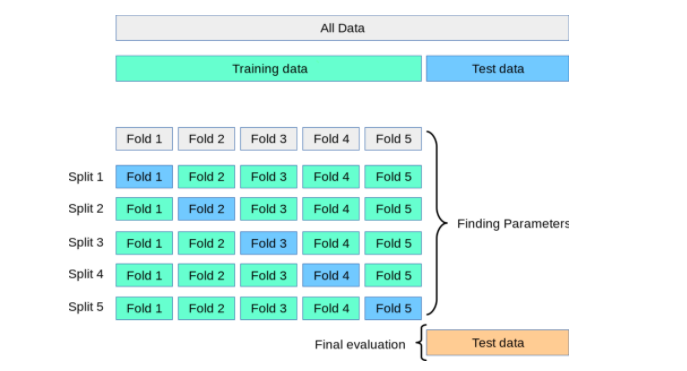

#### 2.2. K-folding estratificado

Como estamos trabajando con un problema de clasificación, utilizaremos una variante llamada **Stratified K-Fold**, que intenta mantener en cada fold una proporción de clases similar a la existente en el conjunto de datos original:

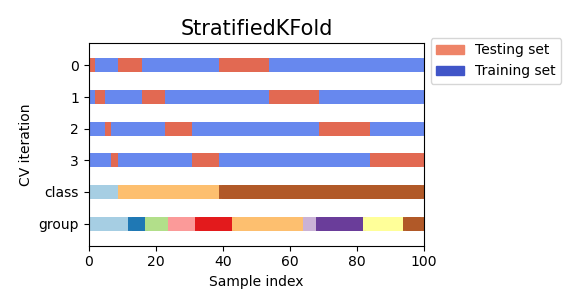

En Scikit-Learn se implementa mediante [`StratifiedKFold`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedKFold.html). Su principal parámetro es el número de divisiones (`n_splits`):

```python
n_splits = 5

from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state = 42)
```

In [69]:
n_splits = 5

from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state = 42)

## 3. Un primer modelo: KNN

### 3.1. Explicación del modelo KNN

El algoritmo **K-Nearest Neighbors (KNN)** clasifica una nueva observación a partir de las muestras etiquetadas que se encuentran más cerca de ella en el espacio de atributos.

Para realizar una predicción, considera las `K` muestras vecinas más cercanas (*Nearest Neighbors*) y asigna la clase más frecuente entre ellas.

El número de vecinos `K` es, por lo tanto, un **hiperparámetro** del modelo. Su elección puede afectar considerablemente el resultado:

* Con valores pequeños de `K`, la clasificación depende de muy pocas muestras cercanas y puede ser muy sensible a pequeñas variaciones de los datos.
* Con valores mayores de `K`, la decisión considera un conjunto más amplio de muestras y genera límites de decisión más suavizados.

### 3.2. Búsqueda del valor óptimo de K

En lugar de elegir arbitrariamente un valor de `K`, vamos a **probar diferentes valores y evaluar su desempeño mediante la validación cruzada** que definimos anteriormente.

Para ello utilizaremos [`cross_validate`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_validate.html). Esta función recibe el modelo, nuestros datos `X` e `Y` y el esquema de validación `skf`. Para cada fold, `cross_validate` se encarga internamente de:

1. entrenar (`fit`) el modelo utilizando los folds de entrenamiento;
2. evaluarlo sobre el fold de validación;
3. calcular la métrica solicitada.

En este caso utilizaremos la Precisión Global o **accuracy** como métrica y guardaremos tanto el resultado sobre los datos de entrenamiento como sobre los datos de validación. La precisión global representa la proporción de muestras clasificadas correctamente respecto del total de muestras evaluadas:

$$
Accuracy = \frac{TP + TN}{TP + TN + FP + FN}
$$

donde:

- **TP**: verdaderos positivos (*True Positives*)
- **TN**: verdaderos negativos (*True Negatives*)
- **FP**: falsos positivos (*False Positives*)
- **FN**: falsos negativos (*False Negatives*)

El *Accuracy* toma valores entre 0 y 1, donde valores cercanos a 1 indican una mayor proporción de clasificaciones correctas.

Como queremos encontrar un valor adecuado de `K`, repetiremos este procedimiento para valores entre 1 y 15. Para ello utilizaremos un `for`:

```python
from sklearn.model_selection import cross_validate
from sklearn.neighbors import KNeighborsClassifier

valores_K = range(1, 16)

resultados_train = np.zeros(len(valores_K))
resultados_test = np.zeros(len(valores_K))

for k_idx, k in enumerate(valores_K):

    print(f'Probando K = {k}')

    # Definimos un modelo KNN para el valor actual de K
    modelo_prueba = KNeighborsClassifier(n_neighbors=k)

    # Evaluamos el modelo mediante validación cruzada usando solo las muestras de entrenamiento
    resultados_KNN = cross_validate(modelo_prueba, X_train, Y_train, cv=skf, scoring='accuracy', return_train_score=True)

    # Guardamos el accuracy promedio obtenido en los folds
    resultados_train[k_idx] = resultados_KNN['train_score'].mean()
    resultados_test[k_idx] = resultados_KNN['test_score'].mean()
```

En cada iteración del `for` estamos, por lo tanto, evaluando **un modelo KNN diferente**. El esquema `skf` mantiene las mismas 5 particiones, pero cambia el valor de `n_neighbors`.

Al finalizar tendremos, para cada valor de `K`, dos resultados:

* `resultados_train`: precisión promedio obtenida las muestras utilizadas para entrenamiento.
* `resultados_test`: precisión promedio obtenida sobre las muestras utilizadas para validación.

La comparación entre ambas curvas nos permitirá analizar cómo cambia el comportamiento del modelo al aumentar `K` y seleccionar una configuración adecuada.

In [70]:
from sklearn.model_selection import cross_validate
from sklearn.neighbors import KNeighborsClassifier

valores_K = range(1, 16)

resultados_train = np.zeros(len(valores_K))
resultados_test = np.zeros(len(valores_K))

for k_idx, k in enumerate(valores_K):

    print(f'Probando K = {k}')

    # Definimos un modelo KNN para el valor actual de K
    modelo_prueba = KNeighborsClassifier(n_neighbors=k)

    # Evaluamos el modelo mediante validación cruzada usando solo las muestras de entrenamiento
    #resultados_KNN = cross_validate(modelo_prueba, X_train, Y_train, cv=skf, scoring='accuracy', return_train_score=True)
    resultados_KNN = cross_validate(modelo_prueba, X_train, Y_train, cv=skf, scoring='balanced_accuracy', return_train_score=True)

    # Guardamos el accuracy promedio obtenido en los folds
    print(f'train_score: {resultados_KNN['train_score']}; test_score: {resultados_KNN['test_score']}')
    resultados_train[k_idx] = np.median(resultados_KNN['train_score'])#resultados_KNN['train_score'].mean()
    resultados_test[k_idx] = np.median(resultados_KNN['test_score']) #resultados_KNN['test_score'].mean()

Probando K = 1
train_score: [1. 1. 1. 1. 1.]; test_score: [0.99752475 1.         1.         1.         0.99772727]
Probando K = 2
train_score: [0.99938424 0.99938424 0.99876543 0.99876543 0.99938424]; test_score: [0.99752475 1.         0.99509804 0.99509804 0.99772727]
Probando K = 3
train_score: [1.         0.99938424 0.99876543 0.99876543 0.99938424]; test_score: [0.99752475 1.         0.99754902 0.99509804 0.99772727]
Probando K = 4
train_score: [0.99876847 0.99753695 0.99814815 0.99814815 0.99815271]; test_score: [0.99752475 1.         0.99509804 0.99509804 0.99525203]
Probando K = 5
train_score: [0.998199   0.99696747 0.99757867 0.99757997 0.99815271]; test_score: [0.99752475 1.         0.99509804 0.99509804 0.99772727]
Probando K = 6
train_score: [0.99696747 0.99635171 0.99696139 0.99757997 0.99692118]; test_score: [0.99752475 0.99752475 0.99509804 0.99509804 0.99030153]
Probando K = 7
train_score: [0.99696747 0.99635171 0.99757867 0.99757997 0.99692118]; test_score: [0.99752475 

Podemos usar la función `argmax` que nos devuelve el íncide del valor máximo, para averiguar con qué valor de `K` obtuvimos el mejor resultado de precisión en `resultados_test`:

```python
ind = np.argmax(resultados_test)
best_K = valores_K[ind]
best_acc = resultados_test[ind]
```

In [71]:
ind = np.argmax(resultados_test)
best_K = valores_K[ind]
best_acc = resultados_test[ind]

Teniéndolos así, los podemos plotear para hacer un análisis del impacto de los K vecinos:

```python
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(valores_K, resultados_train, label='Train')
ax.plot(valores_K, resultados_test, label='Test')

ax.axvline(best_K, color='red', linestyle='--', label=f'Mejor K = {best_K}')

ax.set_title('Exactitud del modelo KNN')
ax.set_xlabel('K vecinos')
ax.set_ylabel('Exactitud (accuracy)')
ax.legend()

plt.show()
```

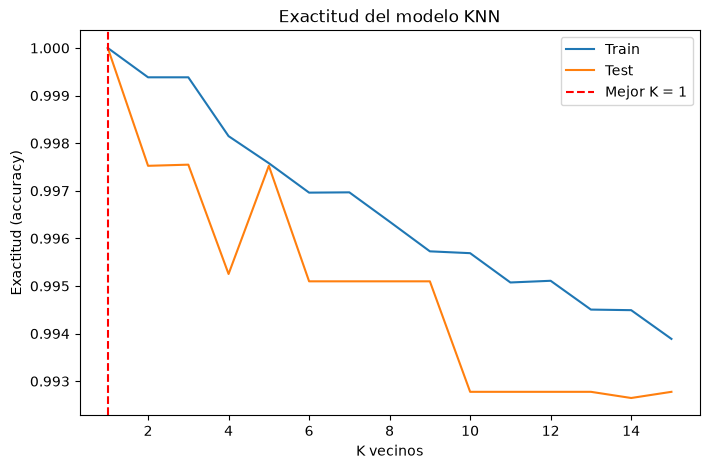

In [72]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(valores_K, resultados_train, label='Train')
ax.plot(valores_K, resultados_test, label='Test')

ax.axvline(best_K, color='red', linestyle='--', label=f'Mejor K = {best_K}')

ax.set_title('Exactitud del modelo KNN')
ax.set_xlabel('K vecinos')
ax.set_ylabel('Exactitud (accuracy)')
ax.legend()

plt.show()

Hacer este tipo de análisis es muy interesante para ver como `n_neighbors` provoca un sobre-ajuste en el conjunto de entrenamiento. Pareciera ser que el valor de exactitud se estabiliza a partir de cierta cantidad de K-vecinos (observar como varía la curva del conjunto `Train` respecto al de `Test`)

### 3.3. Evaluación por clase: la Matriz de Confusión

Hasta ahora utilizamos el **Accuracy** obtenido mediante validación cruzada para comparar distintos valores de `K` y seleccionar la mejor configuración del modelo. Sin embargo, un único valor de Accuracy no nos permite saber **en qué clases está funcionando bien el modelo y cuáles está confundiendo**.

Para analizar esto podemos utilizar una **Matriz de Confusión**.

La matriz compara las **clases reales** de nuestras muestras con las **clases predichas** por el modelo. Cada fila representa una clase real y cada columna la clase asignada por el clasificador. Los valores ubicados sobre la **diagonal principal** corresponden a muestras clasificadas correctamente, mientras que los valores fuera de la diagonal representan errores de clasificación entre clases.

Una vez encontrado el valor óptimo de `K`, definimos el modelo seleccionado y lo entrenamos utilizando `X_train` e `Y_train`. Luego utilizamos este modelo para predecir las clases de las muestras que habíamos reservado para la evaluación (`X_val`):

```python
# Definimos el modelo con el mejor K encontrado
modelo_KNN_elegido = KNeighborsClassifier(n_neighbors=best_K)

# Entrenamos utilizando las muestras del conjunto de entrenamiento
modelo_KNN_elegido.fit(X_train, Y_train)

# Predecimos las clases del conjunto de validación
Y_pred_KNN = modelo_KNN_elegido.predict(X_val)
```

Recordemos que las muestras de `X_val` e `Y_val` **no participaron del entrenamiento ni de la búsqueda del valor óptimo de `K`**. Por lo tanto, podemos utilizarlas para realizar una evaluación independiente del modelo seleccionado.

A partir de las clases reales (`Y_val`) y las clases predichas (`Y_pred_KNN`) podemos construir y visualizar la Matriz de Confusión:

```python
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

M_KNN = confusion_matrix(Y_val, Y_pred_KNN, labels=range(len(clases)))

disp = ConfusionMatrixDisplay(confusion_matrix=M_KNN, display_labels=clases)

disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Matriz de Confusión - KNN")
plt.show()
```

In [73]:
# Definimos el modelo con el mejor K encontrado
modelo_KNN_elegido = KNeighborsClassifier(n_neighbors=best_K)

# Entrenamos utilizando las muestras del conjunto de entrenamiento
modelo_KNN_elegido.fit(X_train, Y_train)

# Predecimos las clases del conjunto de validación
Y_pred_KNN = modelo_KNN_elegido.predict(X_val)

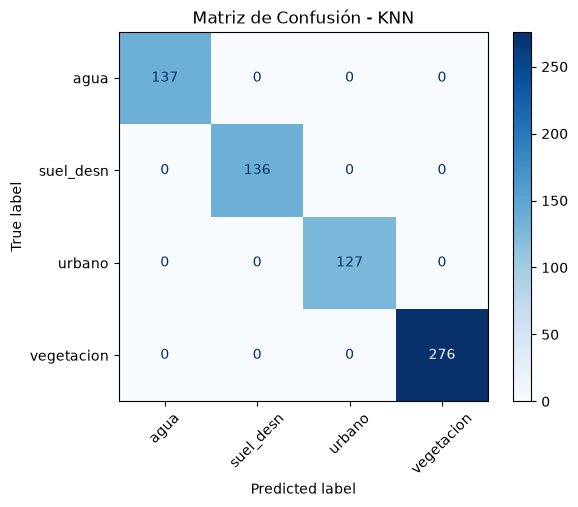

In [74]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

M_KNN = confusion_matrix(Y_val, Y_pred_KNN, labels=range(len(clases)))

disp = ConfusionMatrixDisplay(confusion_matrix=M_KNN, display_labels=clases)

disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Matriz de Confusión - KNN")
plt.show()

### 3.4. Más métricas de evaluación a partir de la Matriz de Confusión

Además de la  **Precisión global**, la Matriz de Confusión nos permite calcular métricas específicas para cada clase. Entre las más utilizadas se encuentran **Precision**, **Recall** y **F1-score**.

La **Precision** responde a la pregunta:

> De todas las muestras que el modelo clasificó como una determinada clase, ¿cuántas pertenecían realmente a esa clase?

$$
\text{Precision}(i) = \frac{TP(i)}{TP(i) + FP(i)}
$$

Una Precision baja indica que estamos incluyendo dentro de una clase muestras que en realidad pertenecen a otras clases. En Teledetección esto está relacionado con el **error de comisión**:

$$
\text{Error de comisión} = 1 - \text{Precision}
$$

El **Recall** responde a una pregunta diferente:

> De todas las muestras que realmente pertenecían a una determinada clase, ¿cuántas fueron correctamente identificadas?

$$
\text{Recall}(i) = \frac{TP(i)}{TP(i) + FN(i)}
$$

Un Recall bajo indica que estamos dejando sin detectar muestras que realmente pertenecían a esa clase. En Teledetección está relacionado con el **error de omisión**:

$$
\text{Error de omisión} = 1 - \text{Recall}
$$

Finalmente, el **F1-score** combina Precision y Recall en una única medida:

$$
F1(i) = 2 \times
\frac{\text{Precision}(i) \times \text{Recall}(i)}
{\text{Precision}(i) + \text{Recall}(i)}
$$

El F1-score será alto cuando el modelo presente simultáneamente buenos valores de Precision y Recall para una clase.

Estas métricas pueden obtenerse directamente mediante `classification_report`:

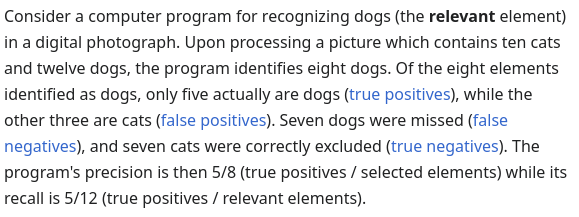

```python
from sklearn.metrics import classification_report

print(classification_report(Y_val, Y_pred_KNN, target_names=clases))
```


In [75]:
from sklearn.metrics import classification_report

print(classification_report(Y_val, Y_pred_KNN, target_names=clases))

              precision    recall  f1-score   support

        agua       1.00      1.00      1.00       137
   suel_desn       1.00      1.00      1.00       136
      urbano       1.00      1.00      1.00       127
  vegetacion       1.00      1.00      1.00       276

    accuracy                           1.00       676
   macro avg       1.00      1.00      1.00       676
weighted avg       1.00      1.00      1.00       676



## 4. Árboles de decisión (Decision Trees)


En un Árbol de Decisión, las muestras se separan sucesivamente mediante reglas basadas en los atributos hasta llegar a una predicción de clase. La profundidad máxima del árbol (`max_depth`) controla cuántas divisiones puede realizar y, por lo tanto, su complejidad. Al igual que ocurría con `n_neighbors` en KNN, la elección de `max_depth` puede afectar la capacidad del modelo para generalizar.

### 4.1. Selección de profundidad

A continuación analizaremos cuál es el efecto del parámetro de profundidad o `max_depth`, usando K-folding con `n_splits = 5` al igual que con KNN. Sin embargo, aquí probaremos una gama de valores de profundidad más amplia (de 2 a 24), con lo cual este proceso probablemente lleve más tiempo en correr. Re-utilizaremos el K-Fold que definimos para KNN, el cual guardamos en la variable `skf`.

```python
from sklearn import tree

valores_MD = np.arange(2, 25)

resultados_train_DT = np.zeros(len(valores_MD))
resultados_test_DT = np.zeros(len(valores_MD))

for md_idx, md in enumerate(valores_MD):

    print(f'Probando con max_depth = {md}')

    modelo_DT = tree.DecisionTreeClassifier(max_depth=md, random_state=42)

    resultados_DT = cross_validate(modelo_DT, X_train, Y_train, cv=skf, scoring='accuracy', return_train_score=True)

    resultados_train_DT[md_idx] = resultados_DT['train_score'].mean()
    resultados_test_DT[md_idx] = resultados_DT['test_score'].mean()
```

In [ ]:
from sklearn import tree

valores_MD = np.arange(2, 25)

resultados_train_DT = np.zeros(len(valores_MD))
resultados_test_DT = np.zeros(len(valores_MD))

for md_idx, md in enumerate(valores_MD):

    print(f'Probando con max_depth = {md}')

    modelo_DT = tree.DecisionTreeClassifier(max_depth=md, random_state=42)

    resultados_DT = cross_validate(modelo_DT, X_train, Y_train, cv=skf, scoring='accuracy', return_train_score=True)

    resultados_train_DT[md_idx] = resultados_DT['train_score'].mean()
    resultados_test_DT[md_idx] = resultados_DT['test_score'].mean()

Probando con max_depth = 2
Probando con max_depth = 3
Probando con max_depth = 4
Probando con max_depth = 5
Probando con max_depth = 6
Probando con max_depth = 7
Probando con max_depth = 8
Probando con max_depth = 9
Probando con max_depth = 10
Probando con max_depth = 11
Probando con max_depth = 12
Probando con max_depth = 13
Probando con max_depth = 14
Probando con max_depth = 15
Probando con max_depth = 16
Probando con max_depth = 17
Probando con max_depth = 18
Probando con max_depth = 19
Probando con max_depth = 20
Probando con max_depth = 21
Probando con max_depth = 22
Probando con max_depth = 23
Probando con max_depth = 24


In [77]:
resultados_DT['test_score']

array([1.        , 0.99259259, 0.99074074, 0.9962963 , 0.99074074])

Calculemos los promedios para poder obtener el mejor _acuracy_ medio, de manera similar a como lo hicimos con KNN:

```python
#Busco el mejor resultado
ind_DT = np.argmax(resultados_test_DT)
best_prof = valores_MD[ind_DT]
best_acc = resultados_test_DT[ind_DT]
print(f'El mejor resultado en el conjunto de testeo fue obtenido para un arbol de profundidad {best_prof} y una exactitud de {best_acc:.3f}')
```

In [78]:
#Busco el mejor resultado
ind_DT = np.argmax(resultados_test_DT)
best_prof_dt = valores_MD[ind_DT]
best_acc_dt = resultados_test_DT[ind_DT]
print(f'El mejor resultado en el conjunto de testeo fue obtenido para un arbol de profundidad {best_prof_dt} y una exactitud de {best_acc_dt:.3f}')

El mejor resultado en el conjunto de testeo fue obtenido para un arbol de profundidad 5 y una exactitud de 0.995


Podemos ver de manera gráfica dónde se situa el valor `max_depth` con el que se logró la mejor profundidad:

```python
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(valores_MD, resultados_train_DT, label='Train')
ax.plot(valores_MD, resultados_test_DT, label='Test')

ax.axvline(best_prof, color='red', linestyle='--', label=f'Mejor MD = {best_prof}')

ax.set_title('Exactitud del modelo DT')
ax.set_xlabel('Max. prof.')
ax.set_ylabel('Exactitud (accuracy)')
ax.legend()

plt.show()
```

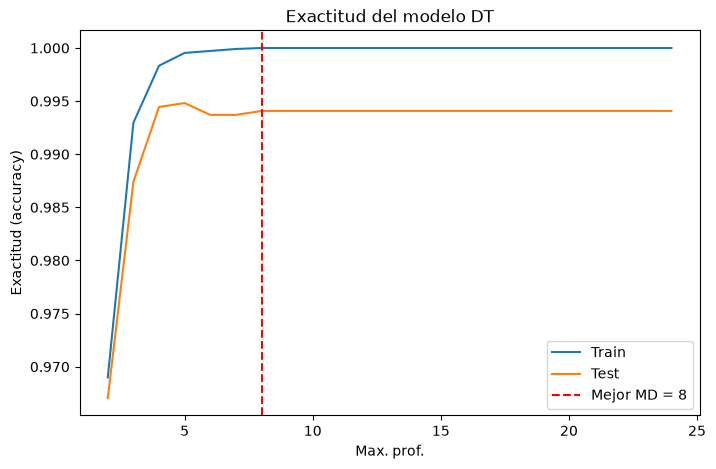

In [79]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(valores_MD, resultados_train_DT, label='Train')
ax.plot(valores_MD, resultados_test_DT, label='Test')

ax.axvline(best_prof, color='red', linestyle='--', label=f'Mejor MD = {best_prof}')

ax.set_title('Exactitud del modelo DT')
ax.set_xlabel('Max. prof.')
ax.set_ylabel('Exactitud (accuracy)')
ax.legend()

plt.show()

### 4.2. Visualización del Árbol de Decisión

Una ventaja de los **Árboles de Decisión** es que podemos visualizar las reglas que el modelo fue construyendo para separar las distintas clases. Una vez seleccionada la mejor profundidad (`best_prof`), creamos y entrenamos el modelo utilizando todas las muestras disponibles:

```python
modelo_DT_elegido = tree.DecisionTreeClassifier(max_depth=best_prof,random_state=42)

modelo_DT_elegido.fit(X_train, Y_train)
```

Podemos visualizar el árbol utilizando la función `plot_tree` de Scikit-Learn. Se puede jugar con el parámetro `max_depth` para elegir hasta qué profundidad graficar:

```python
fig, ax = plt.subplots(figsize=(20, 10))

tree.plot_tree(modelo_DT_elegido, feature_names=columnas_x, class_names=clases, filled=True, max_depth=3)

plt.show()
```

En cada nodo podemos observar la **regla utilizada para dividir los datos**, la cantidad de muestras presentes y la distribución de las clases. Los nodos terminales (*hojas*) representan las decisiones finales de clasificación.


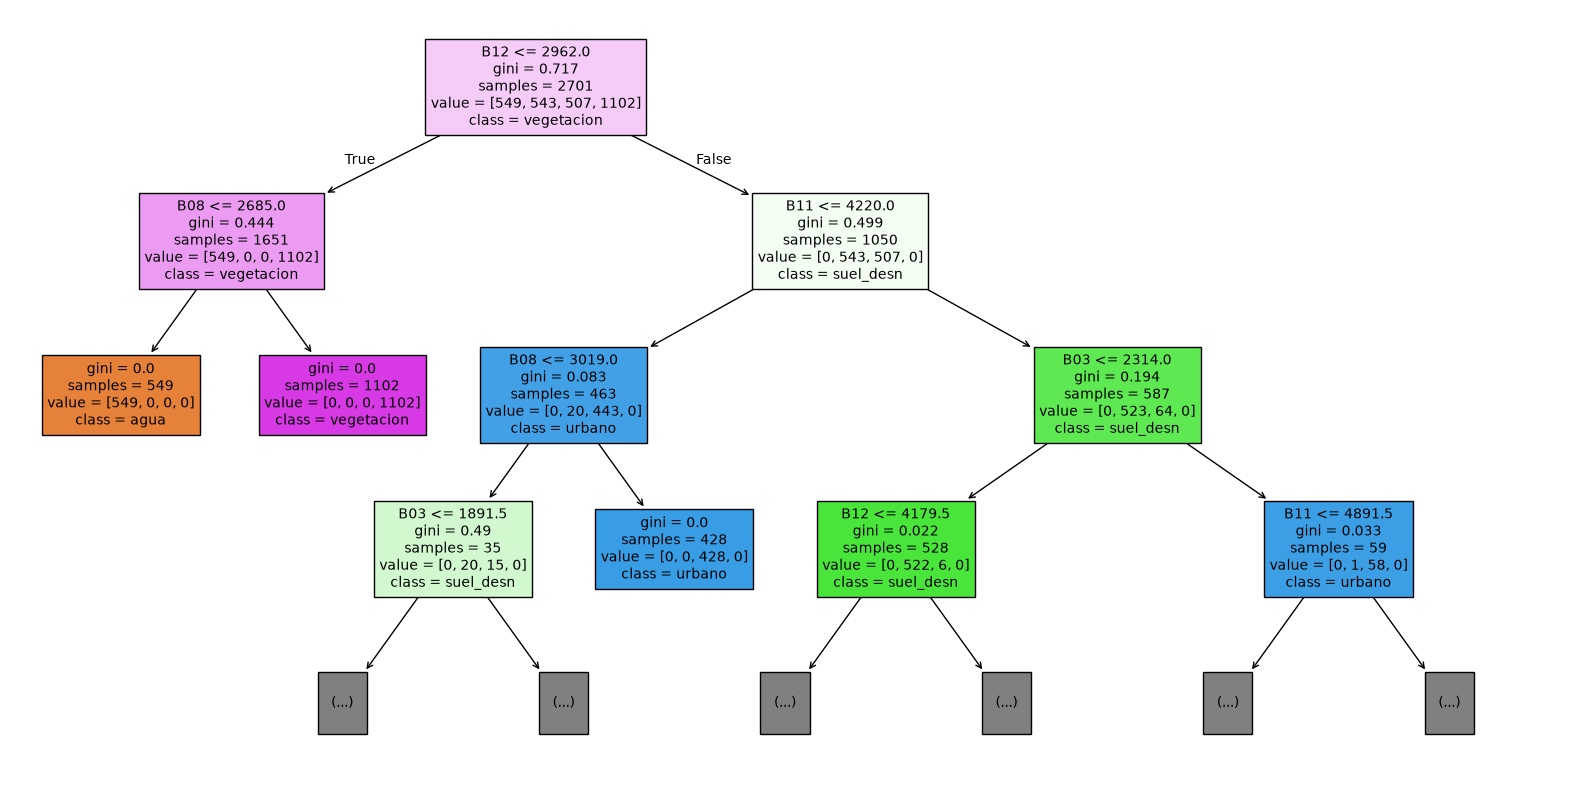

In [80]:
modelo_DT_elegido = tree.DecisionTreeClassifier(max_depth=best_prof,random_state=42)

modelo_DT_elegido.fit(X_train, Y_train)

fig, ax = plt.subplots(figsize=(20, 10))

tree.plot_tree(modelo_DT_elegido, feature_names=columnas_x, class_names=clases, filled=True, max_depth=3)

plt.show()

### 4.3. Evaluación del modelo: Matriz de Confusión y métricas por clase

Al igual que hicimos con **KNN**, una vez seleccionado el mejor valor de `max_depth`, evaluamos el modelo utilizando el conjunto de validación que habíamos reservado previamente.

Recordemos que `modelo_DT_elegido` fue entrenado únicamente con `X_train` e `Y_train`, mientras que `X_val` e `Y_val` **no participaron ni del entrenamiento ni de la búsqueda del hiperparámetro óptimo**.

Por lo tanto, podemos utilizar `X_val` para obtener predicciones independientes del modelo y compararlas con las clases reales almacenadas en `Y_val`.

A partir de estas predicciones construimos la **Matriz de Confusión**:

```python
# Obtenemos las predicciones sobre el conjunto de validación
Y_pred_DT = modelo_DT_elegido.predict(X_val)

# Matriz de Confusión
M_DT = confusion_matrix(Y_val, Y_pred_DT)

disp = ConfusionMatrixDisplay(confusion_matrix=M_DT, display_labels=clases)

disp.plot(cmap='Greens', xticks_rotation=45)
plt.title("Matriz de Confusión - Decision Tree")
plt.show()
```

Finalmente, podemos obtener las métricas de **Precision, Recall y F1-score** para cada clase a partir de las mismas predicciones:

```python
print(classification_report(Y_val, Y_pred_DT, target_names=clases))
```

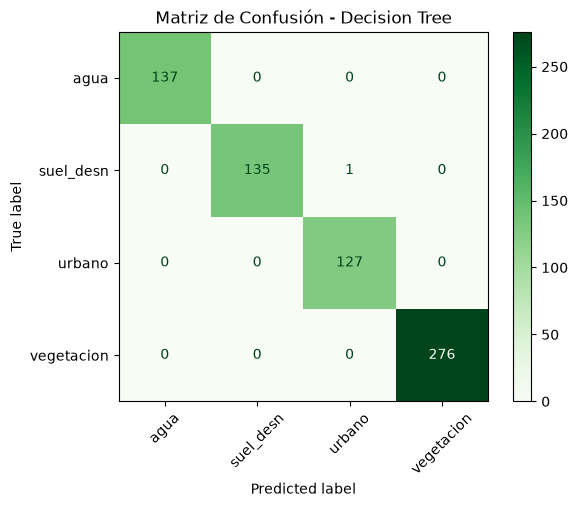

              precision    recall  f1-score   support

        agua       1.00      1.00      1.00       137
   suel_desn       1.00      0.99      1.00       136
      urbano       0.99      1.00      1.00       127
  vegetacion       1.00      1.00      1.00       276

    accuracy                           1.00       676
   macro avg       1.00      1.00      1.00       676
weighted avg       1.00      1.00      1.00       676



In [81]:
# Obtenemos las predicciones sobre el conjunto de validación
Y_pred_DT = modelo_DT_elegido.predict(X_val)

# Matriz de Confusión
M_DT = confusion_matrix(Y_val, Y_pred_DT)

disp = ConfusionMatrixDisplay(confusion_matrix=M_DT, display_labels=clases)

disp.plot(cmap='Greens', xticks_rotation=45)
plt.title("Matriz de Confusión - Decision Tree")
plt.show()

print(classification_report(Y_val, Y_pred_DT, target_names=clases))

## 5. Random Forest

### 5.1. Un conjunto de Árboles de Decisión

**Random Forest (RF)** es un método que combina múltiples Árboles de Decisión. En lugar de realizar la clasificación utilizando un único árbol, se entrenan varios árboles y la predicción final se obtiene combinando sus resultados. Cada árbol se construye utilizando una selección aleatoria de las muestras y de las variables disponibles. Esto permite generar árboles diferentes entre sí y reducir la dependencia de las decisiones particulares de un único árbol.

Entre sus principales hiperparámetros se encuentran:

- `max_depth`: profundidad máxima de cada árbol.
- `n_estimators`: cantidad de árboles que forman el bosque.

Como ya analizamos el efecto de `max_depth` al trabajar con Decision Tree, para simplificar mantendremos la profundidad seleccionada anteriormente (`best_prof`) y analizaremos ahora el efecto de modificar el **número de árboles** (`n_estimators`).

Al igual que hicimos con KNN y Decision Tree, utilizaremos **validación cruzada** para comparar las distintas configuraciones.

### 5.2. Búsqueda de la cantidad óptima de árboles

Volvemos a repetir el mismo ciclo _for_ que hicimos sobre los árboles de decisión y sobre KNN, pero esta vez buscamos evaluar el impacto de `n_estimators`, asumiendo que entrenamos árboles con el valor hallado de `best_prof`. Este proceso será el que más tiempo lleve de todos, ya que en cada iteración se entrenan tantos árboles como cantidad de estimadores que se están evaluando:

```python
from sklearn.ensemble import RandomForestClassifier

valores_estim = [5, 10, 25, 50, 100, 200, 300, 400, 500]

resultados_train_RF = np.zeros(len(valores_estim))
resultados_test_RF = np.zeros(len(valores_estim))

for est_idx, n_estim in enumerate(valores_estim):

    print(f'Probando con n_estimators = {n_estim} y max_depth = {best_prof}')

    modelo_prueba = RandomForestClassifier(n_estimators=n_estim, max_depth=best_prof, random_state=42)

    resultados_RF = cross_validate(modelo_prueba, X_train, Y_train, cv=skf, scoring='accuracy', return_train_score=True)

    resultados_train_RF[est_idx] = resultados_RF['train_score'].mean()
    resultados_test_RF[est_idx] = resultados_RF['test_score'].mean()
```

In [84]:
from sklearn.ensemble import RandomForestClassifier

valores_estim = [5, 10, 25, 50, 100, 200, 300, 400, 500]

resultados_train_RF = np.zeros(len(valores_estim))
resultados_test_RF = np.zeros(len(valores_estim))

for est_idx, n_estim in enumerate(valores_estim):

    print(f'Probando con n_estimators = {n_estim} y max_depth = {best_prof_dt}')

    modelo_prueba = RandomForestClassifier(n_estimators=n_estim, max_depth=best_prof_dt, random_state=42)

    resultados_RF = cross_validate(modelo_prueba, X_train, Y_train, cv=skf, scoring='accuracy', return_train_score=True)

    resultados_train_RF[est_idx] = resultados_RF['train_score'].mean()
    resultados_test_RF[est_idx] = resultados_RF['test_score'].mean()

Probando con n_estimators = 5 y max_depth = 5
Probando con n_estimators = 10 y max_depth = 5
Probando con n_estimators = 25 y max_depth = 5
Probando con n_estimators = 50 y max_depth = 5
Probando con n_estimators = 100 y max_depth = 5
Probando con n_estimators = 200 y max_depth = 5
Probando con n_estimators = 300 y max_depth = 5
Probando con n_estimators = 400 y max_depth = 5
Probando con n_estimators = 500 y max_depth = 5


Buscamos ahora el valor de `n_estimators` para el cual nuestro modelo devuelve la máxima precisión:

```python
#Busco el mejor resultado
ind_RF = np.argmax(resultados_test_RF)
best_estim = valores_estim[ind_RF]
best_acc = resultados_test_RF[ind_RF]
print(f'El mejor resultado en el conjunto de testeo fue obtenido para un Random Forest de profundidad {best_prof}, {best_estim} árboles y una exactitud de {best_acc:.3f}')
```

In [88]:
#Busco el mejor resultado
ind_RF = np.argmax(resultados_test_RF)
best_estim_rf = valores_estim[ind_RF]
best_acc = resultados_test_RF[ind_RF]
print(f'El mejor resultado en el conjunto de testeo fue obtenido para un Random Forest de profundidad {best_prof_dt}, {best_estim_rf} árboles y una exactitud de {best_acc:.3f}')

El mejor resultado en el conjunto de testeo fue obtenido para un Random Forest de profundidad 5, 100 árboles y una exactitud de 0.998


In [86]:
f'{best_acc:.3f}'

'0.998'

Si graficamos la exactitud en función de la Cantidad de Árboles, veremos cómo se estabiliza el _Accuracy_ a partir de cierta cantidad de `n_estimators`. Este análisis es útil para entender que no nos hace falta una excesiva cantidad de árboles para lograr buenos resultados:

```python
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(valores_estim, resultados_train_RF, label='Train')
ax.plot(valores_estim, resultados_test_RF, label='Test')

ax.axvline(best_estim, color='red', linestyle='--', label=f'Mejor NE = {best_estim}')

ax.set_title(f'Exactitud en función de la cantidad de árboles, usando max_depth = {best_prof}')
ax.set_xlabel('N. Estimators')
ax.set_ylabel('Exactitud (accuracy)')
ax.legend()

plt.show()
```

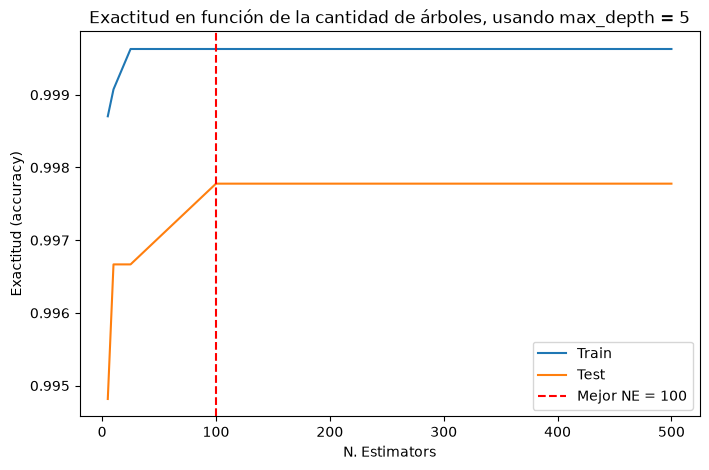

In [90]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(valores_estim, resultados_train_RF, label='Train')
ax.plot(valores_estim, resultados_test_RF, label='Test')

ax.axvline(best_estim_rf, color='red', linestyle='--', label=f'Mejor NE = {best_estim_rf}')

ax.set_title(f'Exactitud en función de la cantidad de árboles, usando max_depth = {best_prof_dt}')
ax.set_xlabel('N. Estimators')
ax.set_ylabel('Exactitud (accuracy)')
ax.legend()

plt.show()

### 5.3. Evaluación del modelo seleccionado

Una vez seleccionado el número de árboles (`best_estim`), definimos nuestro modelo de **Random Forest** utilizando los hiperparámetros elegidos.

Al igual que hicimos con KNN y Decision Tree, entrenamos el modelo utilizando únicamente `X_train` e `Y_train` y luego evaluamos su desempeño sobre las muestras independientes que habíamos reservado en `X_val` e `Y_val`.

```python
# Definimos el modelo con los hiperparámetros seleccionados
modelo_RF_elegido = RandomForestClassifier(n_estimators=best_estim, max_depth=best_prof, random_state=42)

# Entrenamos utilizando las muestras del conjunto de entrenamiento
modelo_RF_elegido.fit(X_train, Y_train)

# Predecimos las clases del conjunto de validación
Y_pred_RF = modelo_RF_elegido.predict(X_val)

# Matriz de Confusión
M_RF = confusion_matrix(Y_val, Y_pred_RF)

disp = ConfusionMatrixDisplay(confusion_matrix=M_RF, display_labels=clases)

disp.plot(cmap='Oranges', xticks_rotation=45)
plt.title("Matriz de Confusión - Random Forest")
plt.show()

# Métricas por clase
print(classification_report(Y_val, Y_pred_RF, target_names=clases))
```

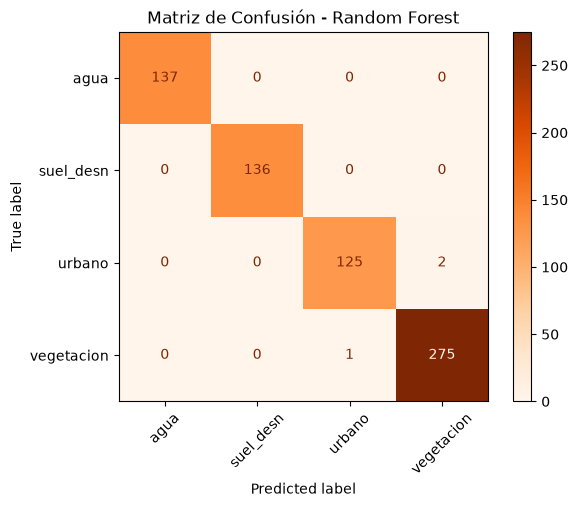

              precision    recall  f1-score   support

        agua       1.00      1.00      1.00       137
   suel_desn       1.00      1.00      1.00       136
      urbano       0.99      0.98      0.99       127
  vegetacion       0.99      1.00      0.99       276

    accuracy                           1.00       676
   macro avg       1.00      1.00      1.00       676
weighted avg       1.00      1.00      1.00       676



In [36]:
# Definimos el modelo con los hiperparámetros seleccionados
modelo_RF_elegido = RandomForestClassifier(n_estimators=best_estim, max_depth=best_prof, random_state=42)

# Entrenamos utilizando las muestras del conjunto de entrenamiento
modelo_RF_elegido.fit(X_train, Y_train)

# Predecimos las clases del conjunto de validación
Y_pred_RF = modelo_RF_elegido.predict(X_val)

# Matriz de Confusión
M_RF = confusion_matrix(Y_val, Y_pred_RF)

disp = ConfusionMatrixDisplay(confusion_matrix=M_RF, display_labels=clases)

disp.plot(cmap='Oranges', xticks_rotation=45)
plt.title("Matriz de Confusión - Random Forest")
plt.show()

# Métricas por clase
print(classification_report(Y_val, Y_pred_RF, target_names=clases))

## 6. Generación de los mapas clasificados

Hasta ahora utilizamos nuestras muestras (`X` e `Y`) para **entrenar, evaluar y seleccionar** diferentes modelos de clasificación mediante validación cruzada. Una vez seleccionados los mejores hiperparámetros para cada algoritmo, podemos pasar a **entrenar el modelo definitivo utilizando todas las muestras disponibles y aplicarlo sobre todos los píxeles de la imagen**. El procedimiento es el mismo para KNN, Decision Tree y Random Forest. A continuación lo realizaremos utilizando **Decision Tree** como ejemplo.

### 6.1. Clasificar todos los píxeles de la imagen con los parámetros óptimos encontrados

Durante la etapa de evaluación utilizamos `cross_validate` y `cross_val_predict`, que entrenaban internamente diferentes modelos utilizando los folds definidos para la validación cruzada.

Ahora que ya seleccionamos los hiperparámetros del modelo, podemos realizar su **entrenamiento definitivo** utilizando todas las muestras disponibles (`X` e `Y`):

```python
modelo_DT_elegido.fit(X, Y)
```

In [37]:
modelo_DT_elegido.fit(X, Y)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",np.int64(8)
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofs

A continuación leemos la imagen completa que queremos clasificar, junto con sus dimensiones (`d, x, y = img.shape`). También conservamos sus metadatos, ya que los utilizaremos posteriormente para guardar el mapa clasificado:

```python
raster_fn = 'output/S2_20181006.tif'

with rasterio.open(raster_fn) as src:
    img = src.read()
    metadatos = src.meta

d, x, y = img.shape
```

In [38]:
raster_fn = 'output/S2_20181006_B02_B03_B04_B08_B11.tif'

with rasterio.open(raster_fn) as src:
    img = src.read()
    metadatos = src.meta

d, x, y = img.shape

Y usamos el modelo definido anteriormente para predecir toda la imagen. Observar que antes de ello, a la imagen debemos darle la estructura de datos que tienen los datos de entrenamiento (X). Eso es lo que hace el comando `img.reshape([d,x*y]).T`: Reordena la matriz para que nos quede un arreglo de dimensiones (bandas, filas x columnas), y luego lo transpone con `.T` para que quede como (filas x columnas, bandas):

```python
#Uso el modelo para clasificar toda la imagen
Y_pred = modelo_DT_elegido.predict(img.reshape([d,x*y]).T)
```

In [39]:
Y_pred = modelo_DT_elegido.predict(img.reshape([d,x*y]).T)

El resultado tiene una sola dimensión (filas x columnas). Si lo quiero re-ordenar como imagen, debo aplicarle un `reshape` nuevamente, pasándole como parámetros las filas y columnas de la imagen original (x e y):

```python
# Reconstruimos el mapa clasificado
class_img_DT = Y_pred.reshape([x, y])

# Lista de etiquetas ordenadas por índice
etiquetas = clases

# Crear un mapa de colores categórico en función de la cantidad de clases
cmap = plt.get_cmap('tab10', len(etiquetas))

fig, ax = plt.subplots(figsize=(26, 20), dpi=300)

im = ax.imshow(class_img_DT, cmap=cmap, vmin=0, vmax=len(etiquetas) - 1)

cbar = fig.colorbar(im, ax=ax, ticks=np.arange(len(etiquetas)))
cbar.ax.set_yticklabels(etiquetas)
cbar.set_label('Clases', rotation=270, labelpad=15)

ax.set_title("Mapa de Clasificación DT", fontsize=20)
ax.axis('off')

plt.show()
```

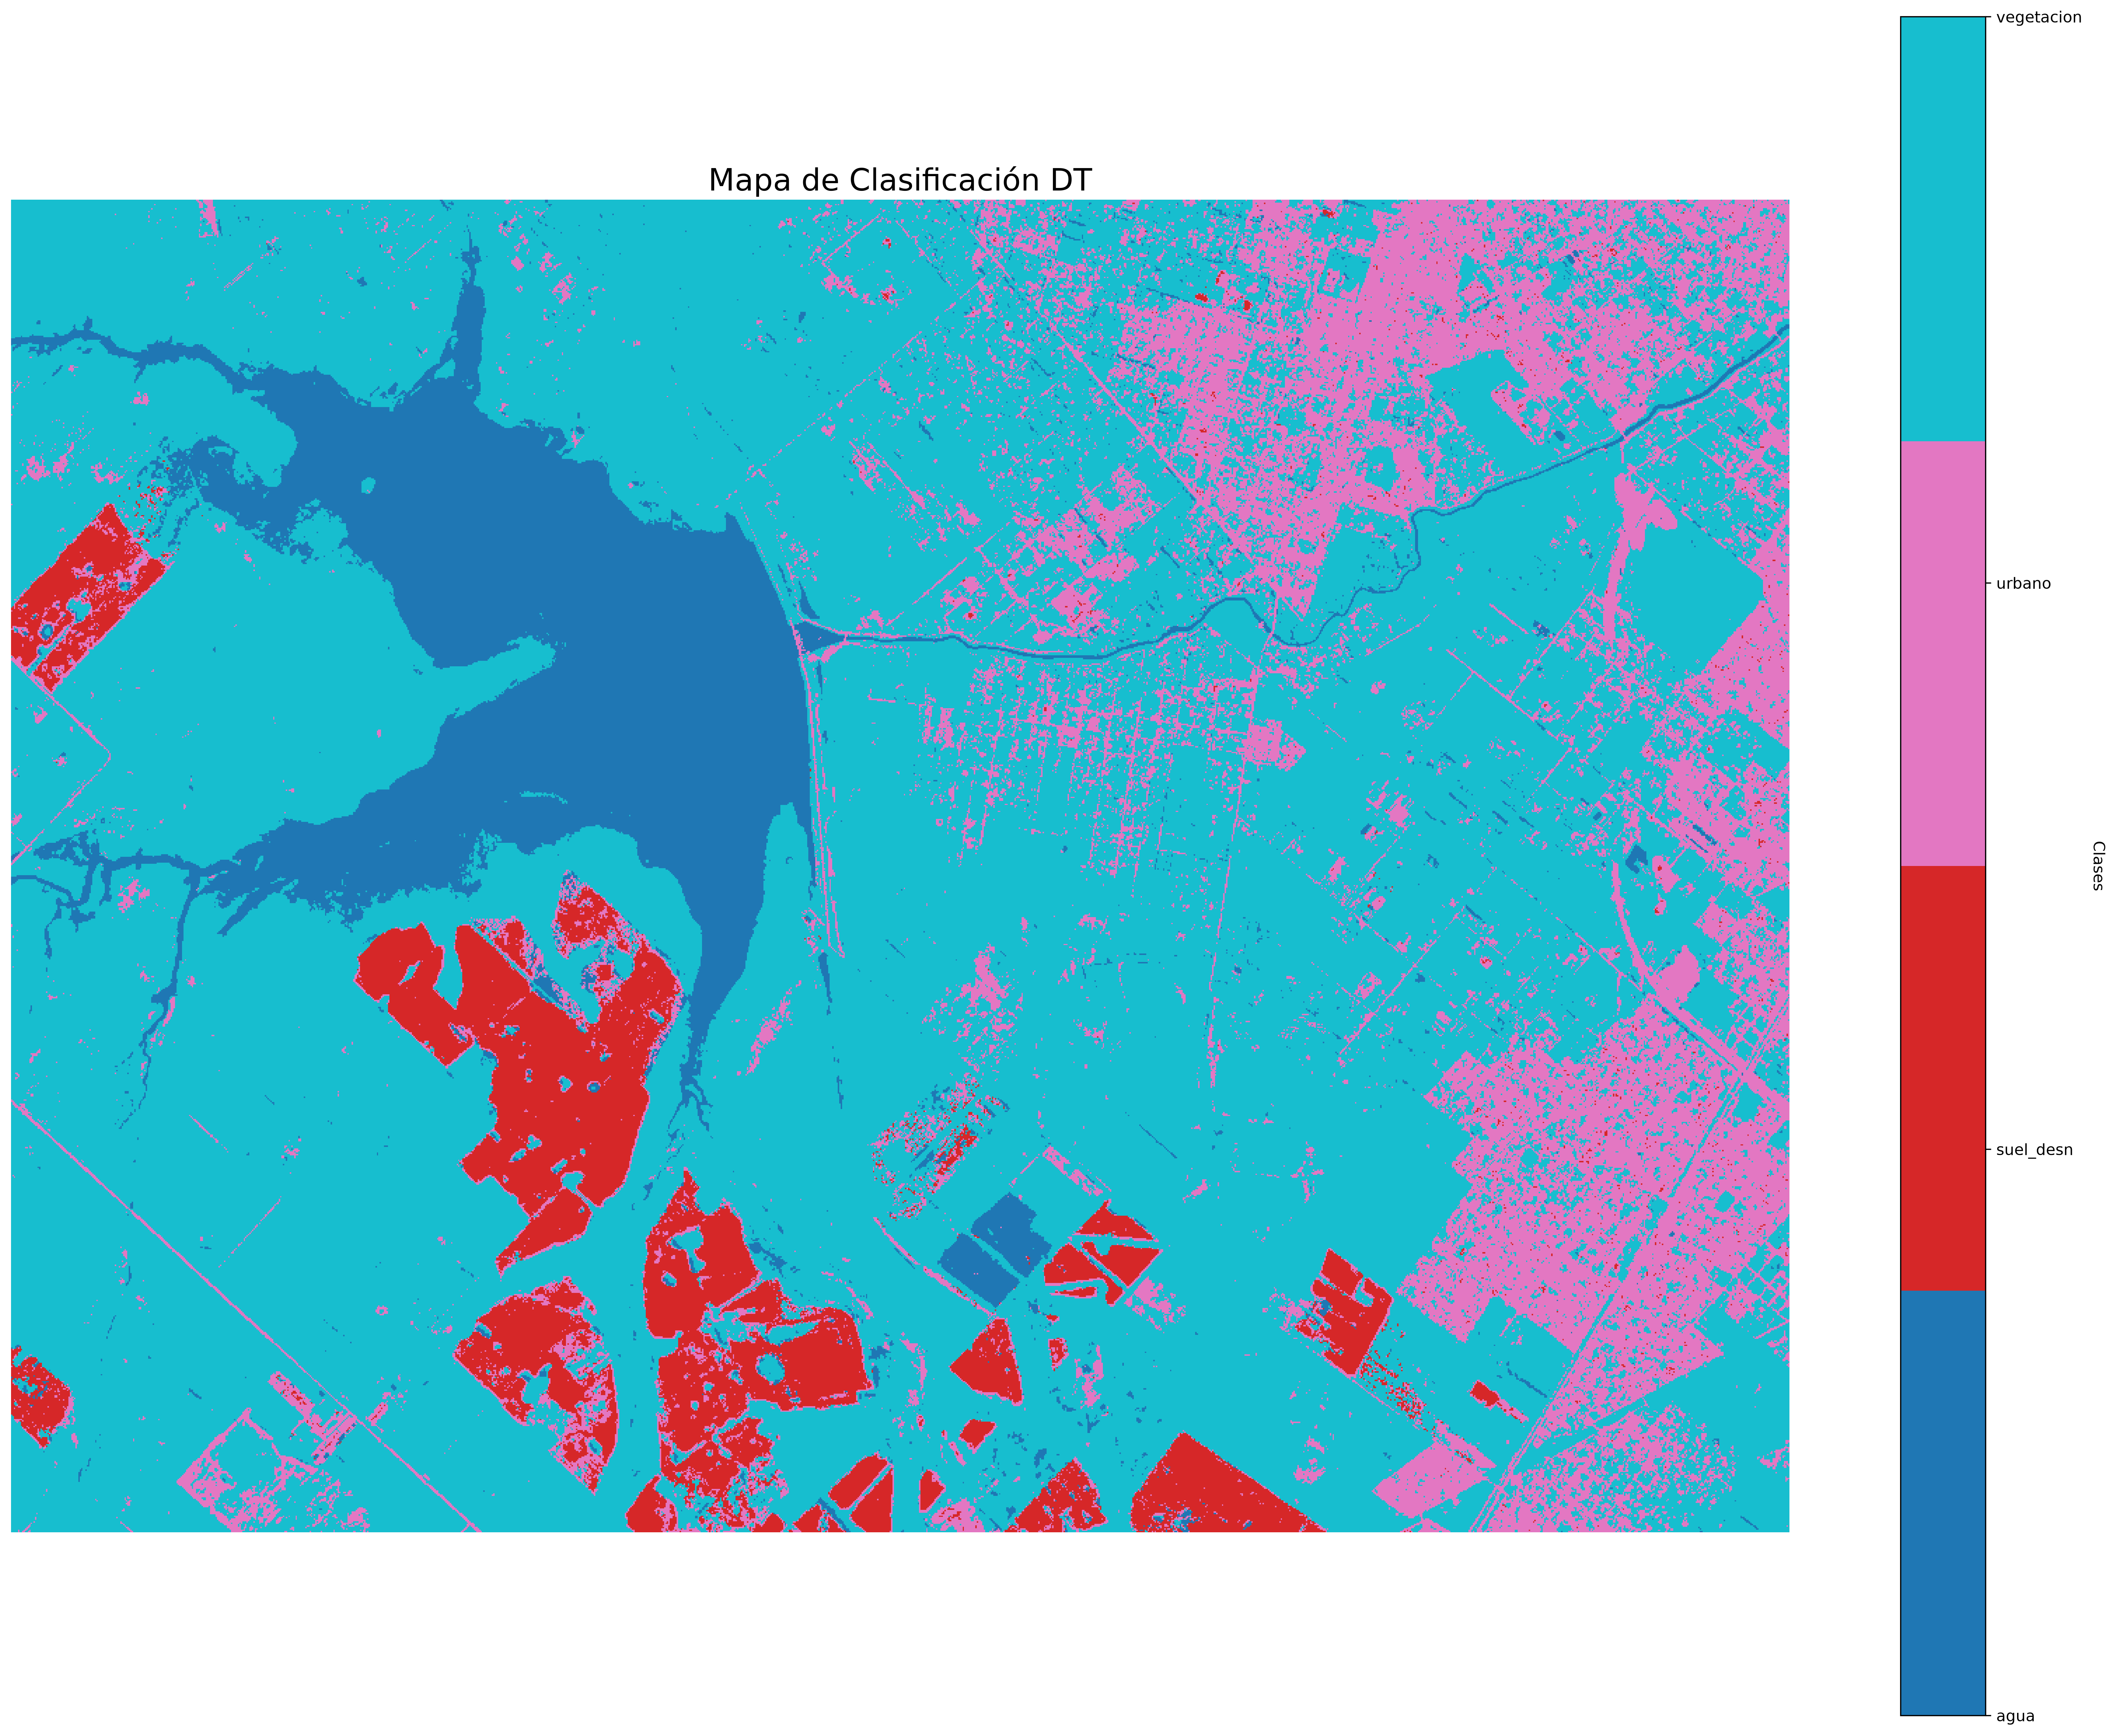

In [40]:
# Reconstruimos el mapa clasificado
class_img_DT = Y_pred.reshape([x, y])

# Lista de etiquetas ordenadas por índice
etiquetas = clases

# Crear un mapa de colores categórico en función de la cantidad de clases
cmap = plt.get_cmap('tab10', len(etiquetas))

fig, ax = plt.subplots(figsize=(26, 20), dpi=300)

im = ax.imshow(class_img_DT, cmap=cmap, vmin=0, vmax=len(etiquetas) - 1)

cbar = fig.colorbar(im, ax=ax, ticks=np.arange(len(etiquetas)))
cbar.ax.set_yticklabels(etiquetas)
cbar.set_label('Clases', rotation=270, labelpad=15)

ax.set_title("Mapa de Clasificación DT", fontsize=20)
ax.axis('off')

plt.show()

Para asegurarme de que los valores de mi clasificación correspondan a las etiquetas de las clases, puedo usar `np.unique()`de Numpy:

```python
np.unique(Y_pred)
```

In [41]:
np.unique(Y_pred)

array([0, 1, 2, 3])

### 6.2. Guardar el mapa clasificado

El mapa obtenido hasta ahora se encuentra almacenado como un arreglo de NumPy. Para poder utilizarlo posteriormente en un SIG, podemos guardarlo como un archivo **GeoTIFF**. Como el mapa clasificado posee la misma extensión, resolución y sistema de referencia que la imagen original, podemos tomar sus metadatos como base y modificar únicamente los atributos necesarios.

La clasificación posee una sola banda y sus valores corresponden a identificadores enteros de las clases, por lo que podemos almacenarla como `uint8`:

```python
#Genero una copia de los metadatos de la imagen original
metadatos_clasif = metadatos.copy()

#Actualizo la cantidad de bandas, y el tipo de dato (no hace falta trabajar a 16 bits)
metadatos_clasif['count'] = 1
metadatos_clasif['dtype'] = 'uint8'
#Guardo un resultado


# Esta línea "concatena" los textos de la lista separados por un "_"
nombre_bandas = "_".join(columnas_x)

out_fn = f'Class_IMG_{nombre_bandas}_CLF_DT_{best_prof}_acc{}.tif'

with rasterio.open(f'output/{out_fn}', 'w', **metadatos_clasif) as dst:
    dst.write(class_img_DT, 1)


In [ ]:
#Genero una copia de los metadatos de la imagen original
metadatos_clasif = metadatos.copy()

#Actualizo la cantidad de bandas, y el tipo de dato (no hace falta trabajar a 16 bits)
metadatos_clasif['count'] = 1
metadatos_clasif['dtype'] = 'uint8'
#Guardo un resultado


# Esta línea "concatena" los textos de la lista separados por un "_"
nombre_bandas = "_".join(columnas_x)

out_fn = f'Class_IMG_{nombre_bandas}_CLF_DT_{best_prof}_Acc${best_acc_dt:.3f}.tif'

with rasterio.open(f'output/{out_fn}', 'w', **metadatos_clasif) as dst:
    dst.write(class_img_DT, 1)

### 6.3. Yapa: Crear un archivo de estilo para visualizar en QGIS

La siguiente celda toma la paleta de colores usada para plotear las clases con `Matplotlib` y crea un archivo de tipo QML con el mismo nombre y en la misma ubicación del archivo GeoTiff clasificado. Esto permite que al abrirlo en QGIS, el ráster se cargue con la misma simbología que vimos aquí, y con la leyenda explicativa de cada clase. Esto va a dar lugar a un texto de archivo plano similar a lo siguiente:


```
<!DOCTYPE qgis PUBLIC 'http://mrcc.com/qgis.dtd' 'SYSTEM'>
<qgis>
  <pipe>
    <rasterrenderer type="paletted" band="1">
      <colorPalette>
        <paletteEntry value="0" color="#1f77b4" label="agua"/>
        <paletteEntry value="1" color="#2ca02c" label="bosque"/>
        <paletteEntry value="2" color="#9467bd" label="humedal"/>
        <paletteEntry value="3" color="#e377c2" label="rural_cultivo"/>
        <paletteEntry value="4" color="#bcbd22" label="rural_sd"/>
        <paletteEntry value="5" color="#17becf" label="urbano"/>
      </colorPalette>
    </rasterrenderer>
  </pipe>
</qgis>
```

El código para recrear lo anterior sería el siguiente:

```python
# Colores de la paleta
cmap = plt.get_cmap('tab10', len(clases))

qml = """<!DOCTYPE qgis PUBLIC 'http://mrcc.com/qgis.dtd' 'SYSTEM'>
<qgis>
  <pipe>
    <rasterrenderer type="paletted" band="1">
      <colorPalette>
"""

for i, clase in enumerate(clases):
    r, g, b, _ = cmap(i)
    r = int(r * 255)
    g = int(g * 255)
    b = int(b * 255)

    qml += f'        <paletteEntry value="{i}" color="#{r:02x}{g:02x}{b:02x}" label="{clase}"/>\n'

qml += """      </colorPalette>
    </rasterrenderer>
  </pipe>
</qgis>
"""

with open(f'output/{out_fn[:-4]}.qml', 'w') as f:
    f.write(qml)
```

<h2 style="color:red;">Ejercicio - Entregable!</h2>

Ya contamos con los modelos seleccionados para **KNN** y **Random Forest**, utilizando los mejores hiperparámetros encontrados durante la etapa de validación cruzada:

- `modelo_KNN_elegido`
- `modelo_RF_elegido`

Estos modelos ya están instanciados con sus respectivos hiperparámetros óptimos, pero todavía falta realizar su **entrenamiento definitivo utilizando todas las muestras disponibles**.

Para cada uno de ellos:

1. Entrená el modelo utilizando todas las muestras (`X` e `Y`):

```python
modelo_elegido.fit(X, Y)
```

2. Utilizá el modelo entrenado para clasificar todos los píxeles de la imagen, siguiendo el mismo procedimiento utilizado anteriormente con **Decision Tree**.

3. Reconstruí la imagen clasificada con las dimensiones espaciales originales.

4. Visualizá el mapa resultante.

5. Guardá el mapa obtenido como archivo **GeoTIFF**.

Realizá este procedimiento primero para `modelo_KNN_elegido` y luego para `modelo_RF_elegido`. Opcionalmente, podés generar el archivo QML con las clases correspondientes para su visualización en QGIS.

In [125]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import cross_validate
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

In [105]:
# --
muestras = pd.read_csv('output/Clase07a_muestras_ejemplo.csv')

# --
clases=list(set(muestras['Clase']))
clases.sort() #ordeno las clases de mi CSV alfabéticamente
clase_dict = {clase:i for i, clase in enumerate(clases)}

# Crear la columna numérica
muestras['Clase_ID'] = muestras['Clase'].map(clase_dict)

# --
columnas_x = ['B02','B03','B04','B08','B11', 'B12']
X = muestras[columnas_x].to_numpy()
Y = muestras['Clase_ID'].to_numpy()

In [106]:
# -- 
X_train, X_val, Y_train, Y_val = train_test_split(X ,Y ,test_size=0.2, stratify=Y, random_state=42)

# --
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state = 42)

In [109]:
# -- Mejor KNN
best_K = 3

# -- Mejor RF
best_prof_dt = 5
best_estim_rf = 100

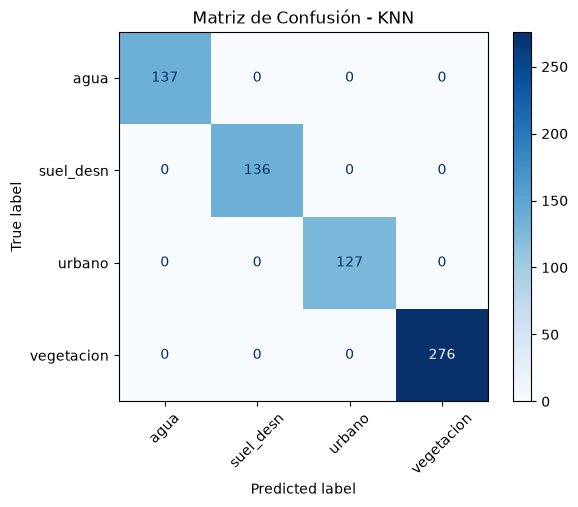

In [110]:
# --
modelo_KNN_elegido = KNeighborsClassifier(n_neighbors=best_K)

# Entrenamos utilizando las muestras del conjunto de entrenamiento
modelo_KNN_elegido.fit(X_train, Y_train)

# Predecimos las clases del conjunto de validación
Y_pred_KNN = modelo_KNN_elegido.predict(X_val)

# --
M_KNN = confusion_matrix(Y_val, Y_pred_KNN, labels=range(len(clases)))

disp = ConfusionMatrixDisplay(confusion_matrix=M_KNN, display_labels=clases)

disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Matriz de Confusión - KNN")
plt.show()

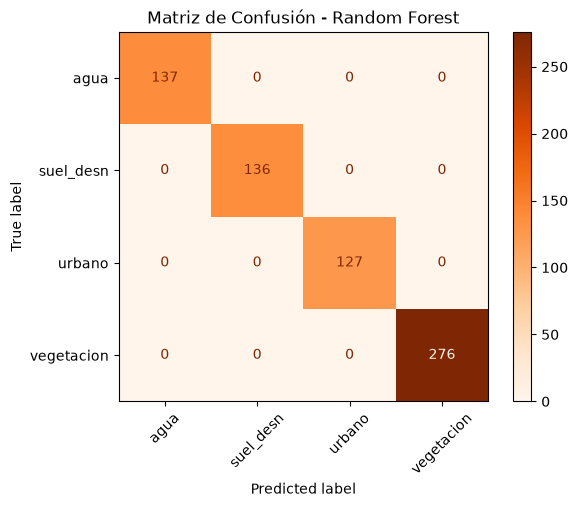

In [112]:
# Definimos el modelo con los hiperparámetros seleccionados
modelo_RF_elegido = RandomForestClassifier(n_estimators=best_estim_rf, max_depth=best_prof_dt, random_state=42)

# Entrenamos utilizando las muestras del conjunto de entrenamiento
modelo_RF_elegido.fit(X_train, Y_train)

# Predecimos las clases del conjunto de validación
Y_pred_RF = modelo_RF_elegido.predict(X_val)

# Matriz de Confusión
M_RF = confusion_matrix(Y_val, Y_pred_RF)

disp = ConfusionMatrixDisplay(confusion_matrix=M_RF, display_labels=clases)

disp.plot(cmap='Oranges', xticks_rotation=45)
plt.title("Matriz de Confusión - Random Forest")
plt.show()

# Métricas por clase
#print(classification_report(Y_val, Y_pred_RF, target_names=clases))

In [113]:
# --
modelo_KNN_elegido.fit(X, Y)

# --
modelo_RF_elegido.fit(X, Y)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap:

In [114]:
raster_fn = 'output/S2_20181006.tif'

with rasterio.open(raster_fn) as src:
    img = src.read()
    metadatos = src.meta

d, x, y = img.shape

In [115]:
# --
Y_pred_KNN = modelo_KNN_elegido.predict(img.reshape([d,x*y]).T)

# --
Y_pred_RF = modelo_RF_elegido.predict(img.reshape([d,x*y]).T)

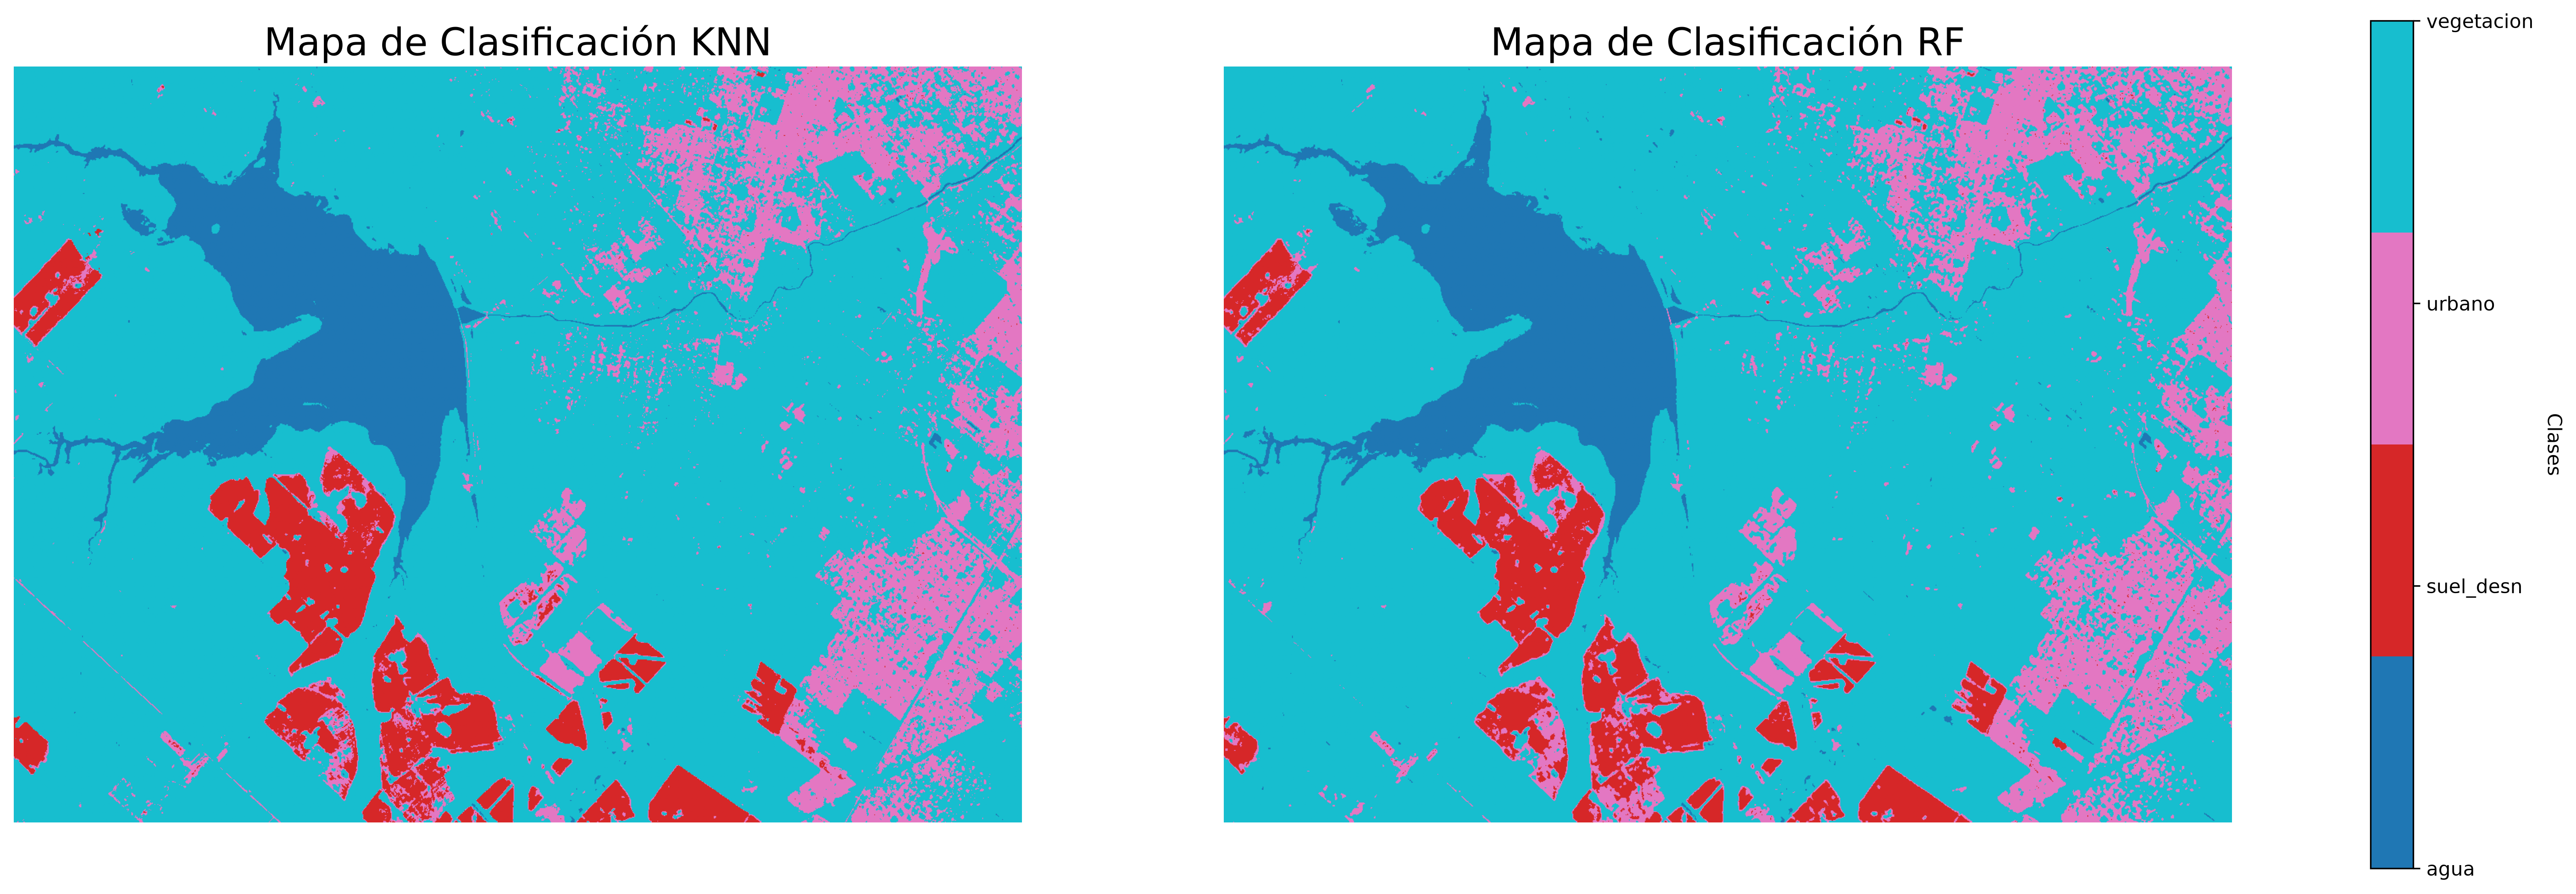

In [121]:
# Reconstruimos el mapa clasificado
class_img_KNN = Y_pred_KNN.reshape([x, y])
class_img_RF = Y_pred_RF.reshape([x, y])

# Lista de etiquetas ordenadas por índice
etiquetas = clases

# Crear un mapa de colores categórico en función de la cantidad de clases
cmap = plt.get_cmap('tab10', len(etiquetas))

fig, ax = plt.subplots(1, 2, figsize=(26, 8), dpi=300)

im1 = ax[0].imshow(class_img_KNN, cmap=cmap, vmin=0, vmax=len(etiquetas) - 1)
im2 = ax[1].imshow(class_img_RF, cmap=cmap, vmin=0, vmax=len(etiquetas) - 1)

cbar = fig.colorbar(im1, ax=ax, ticks=np.arange(len(etiquetas)))
cbar.ax.set_yticklabels(etiquetas)
cbar.set_label('Clases', rotation=270, labelpad=15)

ax[0].set_title("Mapa de Clasificación KNN", fontsize=20)
ax[0].axis('off')
ax[1].set_title("Mapa de Clasificación RF", fontsize=20)
ax[1].axis('off')

plt.show()

In [122]:
#Genero una copia de los metadatos de la imagen original
metadatos_clasif = metadatos.copy()

#Actualizo la cantidad de bandas, y el tipo de dato (no hace falta trabajar a 16 bits)
metadatos_clasif['count'] = 1
metadatos_clasif['dtype'] = 'uint8'
#Guardo un resultado

# Esta línea "concatena" los textos de la lista separados por un "_"
nombre_bandas = "_".join(columnas_x)

out_fn_KNN = f'Class_IMG_{nombre_bandas}_CLF_KNN.tif'
out_fn_RF = f'Class_IMG_{nombre_bandas}_CLF_RF.tif'

# --
with rasterio.open(f'output/{out_fn_KNN}', 'w', **metadatos_clasif) as dst:
    dst.write(class_img_KNN, 1)

# --
with rasterio.open(f'output/{out_fn_RF}', 'w', **metadatos_clasif) as dst:
    dst.write(class_img_RF, 1)

<h2 style="color:red;">Ejercicio - Entregable!</h2>

Entrená un clasificador utilizando **uno de los tres algoritmos trabajados en esta clase** (KNN, Decision Tree o Random Forest). Utilizá como datos de entrada la imagen con el conjunto reducido de bandas que generaste en la **Clase 06** y las muestras correspondientes que preparaste en la **Clase 07a**.

Siguiendo el procedimiento desarrollado en esta clase:

1. Realizá una búsqueda del **hiperparámetro óptimo** del algoritmo seleccionado mediante validación cruzada.
2. Evaluá el modelo elegido y reportá sus **métricas de desempeño**, incluyendo la Matriz de Confusión.
3. Entrená el modelo definitivo utilizando todas las muestras disponibles.
4. Aplicá el modelo entrenado sobre la imagen completa para generar el mapa clasificado.
5. Guardá el resultado como un archivo **GeoTIFF**.

In [123]:
# --
muestras = pd.read_csv('output/Clase07a_muestras_B02_B03_B08_B11.csv')

# --
clases=list(set(muestras['Clase']))
clases.sort() #ordeno las clases de mi CSV alfabéticamente
clase_dict = {clase:i for i, clase in enumerate(clases)}

# Crear la columna numérica
muestras['Clase_ID'] = muestras['Clase'].map(clase_dict)

# --
columnas_x = ['B02','B03','B08','B11']
X = muestras[columnas_x].to_numpy()
Y = muestras['Clase_ID'].to_numpy()

In [124]:
# -- 
X_train, X_val, Y_train, Y_val = train_test_split(X ,Y ,test_size=0.2, stratify=Y, random_state=42)

# --
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state = 42)

In [126]:
# 1. Inicializo el modelo base
rf = RandomForestClassifier(random_state=42)

# 2. Define the grid of parameters to test
param_grid = {
    'n_estimators': [5, 10, 25, 50, 100, 200, 300, 400, 500],
    'max_depth': np.arange(2, 25),
}

# 3. Set up the Grid Search with 5-fold cross-validation
n_splits = 5
cv_strategy = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=cv_strategy, scoring='accuracy', n_jobs=-1)

# 4. Fit the grid search to the data
grid_search.fit(X_train, Y_train)

# 5. Extract the best configuration
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV Score: {grid_search.best_score_:.4f}")

# 6. Get the optimized model instance
best_rf_model = grid_search.best_estimator_

Best Parameters: {'max_depth': np.int64(7), 'n_estimators': 25}
Best CV Score: 0.9926


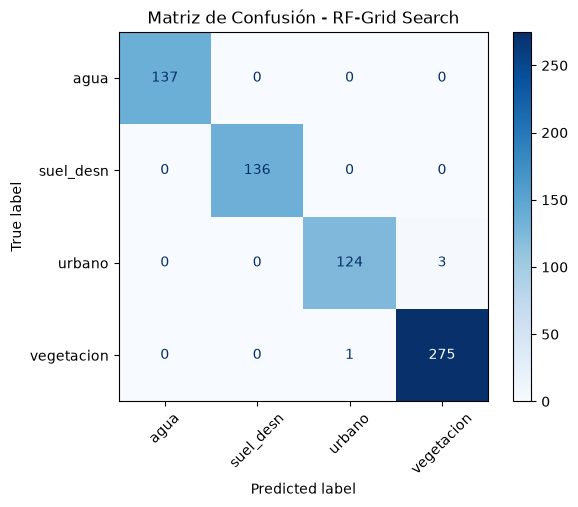

In [127]:
# Predecimos las clases del conjunto de validación
Y_pred_RF2 = best_rf_model.predict(X_val)

# --
M_RF2 = confusion_matrix(Y_val, Y_pred_RF2, labels=range(len(clases)))

disp = ConfusionMatrixDisplay(confusion_matrix=M_RF2, display_labels=clases)

disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Matriz de Confusión - RF-Grid Search")
plt.show()

In [133]:
raster_fn = 'output/S2_20181006_B02_B03_B08_B11.tif'

with rasterio.open(raster_fn) as src:
    img = src.read()
    metadatos = src.meta

d, x, y = img.shape

In [134]:
# --
Y_pred_RF2 = best_rf_model.predict(img.reshape([d,x*y]).T)

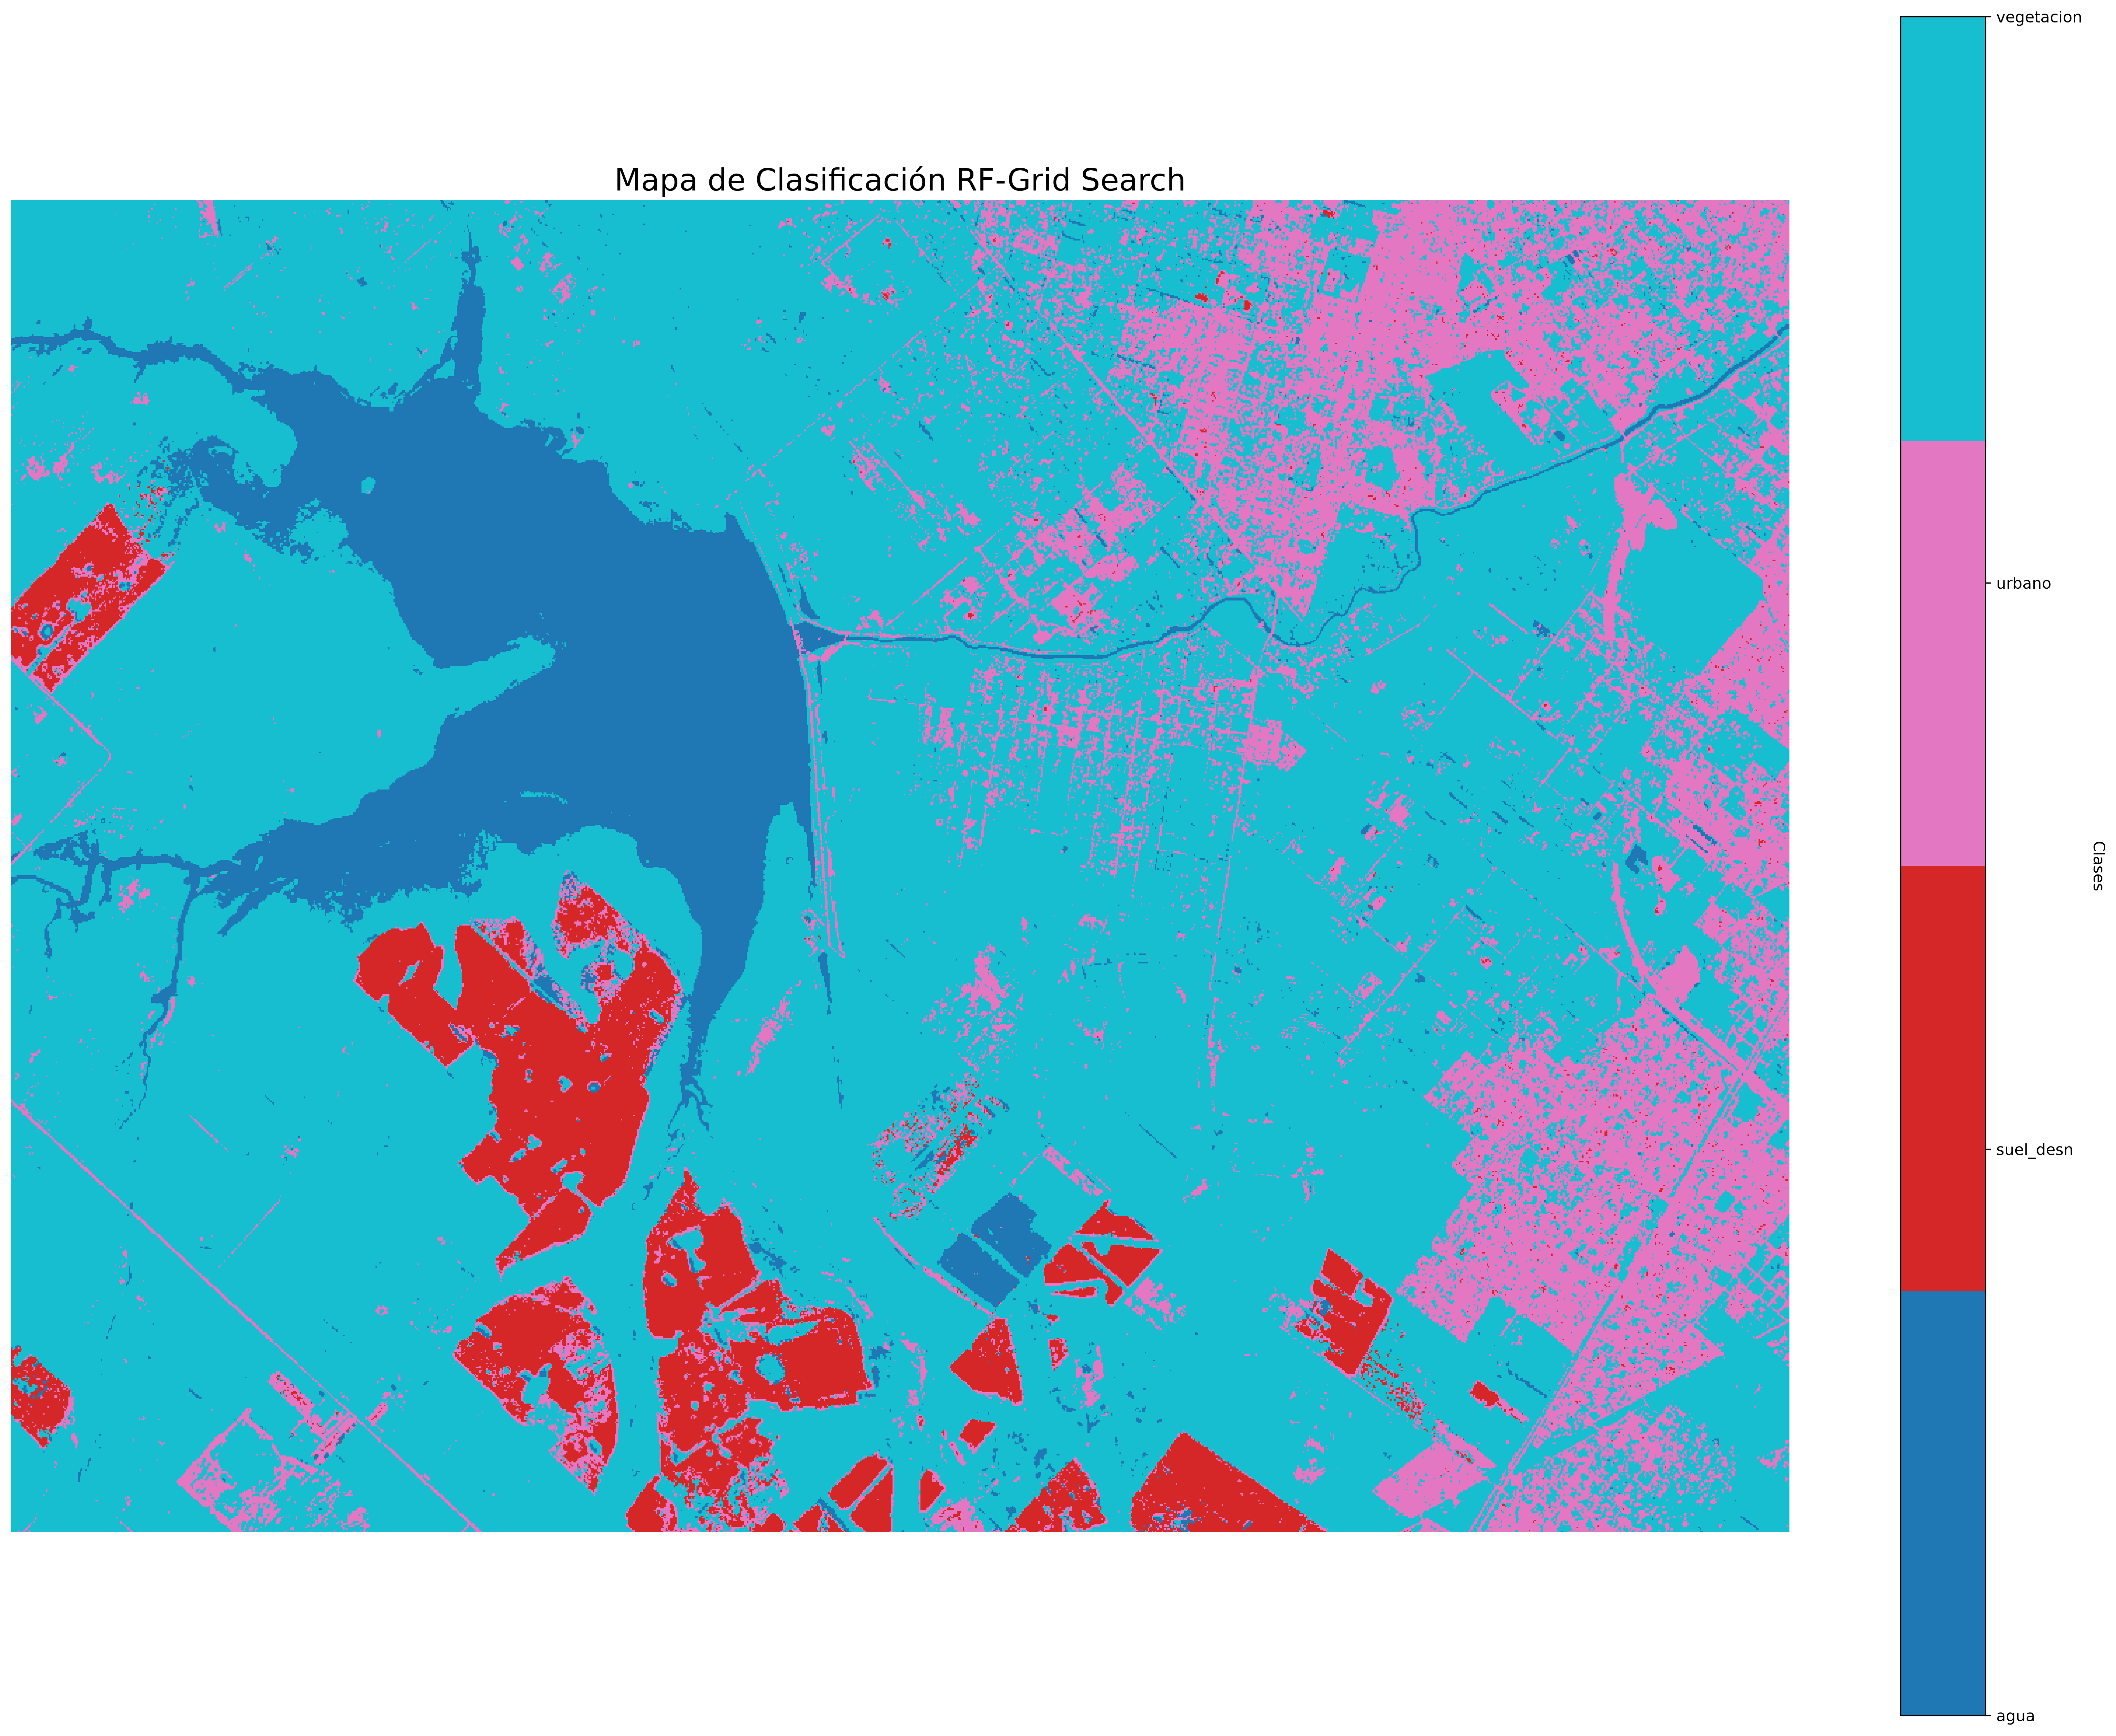

In [135]:
# Reconstruimos el mapa clasificado
class_img_RF2 = Y_pred_RF2.reshape([x, y])

# Lista de etiquetas ordenadas por índice
etiquetas = clases

# Crear un mapa de colores categórico en función de la cantidad de clases
cmap = plt.get_cmap('tab10', len(etiquetas))

fig, ax = plt.subplots(figsize=(26, 20), dpi=300)

im = ax.imshow(class_img_DT, cmap=cmap, vmin=0, vmax=len(etiquetas) - 1)

cbar = fig.colorbar(im, ax=ax, ticks=np.arange(len(etiquetas)))
cbar.ax.set_yticklabels(etiquetas)
cbar.set_label('Clases', rotation=270, labelpad=15)

ax.set_title("Mapa de Clasificación RF-Grid Search", fontsize=20)
ax.axis('off')

plt.show()